In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 928.0 bytes


In [5]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [6]:
df['study_hours'].values

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

In [7]:
type(df['study_hours'].values)

numpy.ndarray

In [8]:
torch.tensor(df['study_hours'].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [9]:
y = torch.tensor(df['grade'].values)
x = torch.tensor(df['study_hours'].values)

In [10]:
x

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [11]:
y

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325,
        15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

In [12]:
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]

In [13]:
x_train

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015], dtype=torch.float64)

In [14]:
y_train

tensor([30.2039, 57.8785, 46.3684, 39.3307, 14.8439, 16.3600, 11.9829, 55.4231,
        40.7430, 41.8775, 11.6774, 57.7253, 50.2683, 21.8403, 21.1532, 21.0328,
        23.5337, 35.6194, 32.2598, 26.5125, 39.6343, 16.6034, 22.3946, 25.9257,
        34.4286, 51.9713, 19.8397, 37.7188, 40.3440, 11.0323, 41.1000, 21.6023,
        13.1809, 60.5736, 53.0421, 52.0637, 25.4048, 14.2856, 44.3952, 28.0325],
       dtype=torch.float64)

In [15]:
x_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [16]:
y_test

tensor([15.6626, 35.4731, 14.6752, 54.4295, 21.3220, 42.1226, 27.4164, 36.6609,
        36.2760, 20.2693], dtype=torch.float64)

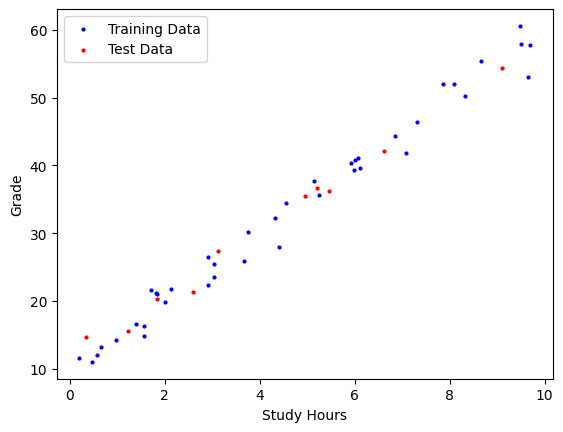

In [17]:
plt.scatter(x_train, y_train, color='blue', s = 4, label='Training Data')
plt.scatter(x_test, y_test, color='red', s = 4, label='Test Data')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.legend()
plt.show()

In [18]:
from torch import nn

class SimpleLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [19]:
torch.manual_seed(42)

model_0 = SimpleLinearRegressionModel()

In [20]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [22]:
with torch.inference_mode():
    y_pred = model_0(x_test)

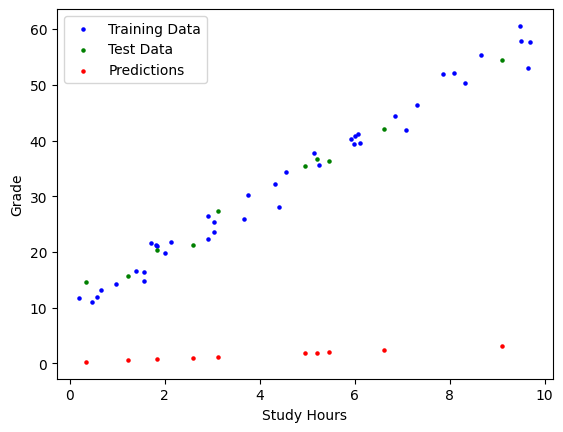

In [23]:
plt.scatter(x_train, y_train, color='b', s = 5, label='Training Data')
plt.scatter(x_test, y_test, color='g', s = 5, label='Test Data')
plt.scatter(x_test, y_pred, color='r', s = 5, label='Predictions')
plt.xlabel('Study Hours')
plt.ylabel('Grade')
plt.legend()
plt.show()

In [24]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

c:\Users\alica\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
torch.manual_seed(42)

epochs = 200
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    pass